#### Libraries

In [27]:
import pandas as pd
import numpy as np

import Orange
from sklearn.model_selection import KFold, cross_validate
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, log_loss, confusion_matrix, roc_auc_score

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import log_loss

import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score

#### Load the Dataset

In [28]:
%store -r X_train_scaled
%store -r X_test_scaled
%store -r X_scaled
%store -r y_train
%store -r y_test
%store -r y_dataset

##### Prepare the Train Dataset

In [29]:
y_train = y_train.astype(str)

train_domain = Orange.data.Domain([Orange.data.ContinuousVariable(str(i)) for i in range(X_train_scaled.shape[1])],
                                  Orange.data.DiscreteVariable('target', values=np.unique(y_train)))

train_data = Orange.data.Table(train_domain, X_train_scaled, y_train)

y_test = y_test.astype(str)
test_domain = Orange.data.Domain([Orange.data.ContinuousVariable(str(i)) for i in range(X_test_scaled.shape[1])],
                                Orange.data.DiscreteVariable('target', values=np.unique(y_test)))

test_data = Orange.data.Table(test_domain, X_test_scaled, y_test)

y_dataset = y_dataset.astype(str)
combined_domain = Orange.data.Domain([Orange.data.ContinuousVariable(str(i)) for i in range(X_scaled.shape[1])],
                                Orange.data.DiscreteVariable('target', values=np.unique(y_dataset)))

combined_data = Orange.data.Table(combined_domain, X_scaled, y_dataset)


#### CN2 Rule Induction

In [30]:
cn2_learner = Orange.classification.rules.CN2Learner()
cn2_classifier = cn2_learner(train_data)

print("Rules:")
for rule in cn2_classifier.rule_list:
    print(rule)

Rules:
IF 0>=0.9981347915867563 THEN target=0 
IF 8>=0.9722712095875048 THEN target=3 
IF 27>=0.0020701044854011413 THEN target=1 
IF 1>=0.996686551508934 THEN target=2 
IF 2>=0.9429605701437909 THEN target=3 
IF 5>=0.912085082067049 THEN target=2 
IF 5>=0.9093707278255514 THEN target=3 
IF 0>=0.9956786637988517 THEN target=0 
IF 8>=0.8952913513555709 THEN target=3 
IF 15>=0.8985807737042836 THEN target=2 
IF 28>=0.9999999999999992 THEN target=1 
IF 29>=4.669839776406453e-15 AND 4>=2.0647698548505873e-06 THEN target=3 
IF 26>=0.0012054399245783054 AND 4>=1.989478715847527e-06 THEN target=2 
IF 12>=0.004190720508968462 THEN target=0 
IF 1>=0.9873510720633824 THEN target=2 
IF 7>=1.986409638450936e-06 THEN target=1 
IF 0>=0.9879728845341222 THEN target=0 
IF 26>=0.0013005330495357366 THEN target=2 
IF 25>=1.0 THEN target=3 
IF 17>=0.015472225206833556 THEN target=3 
IF 18>=0.018547626532535944 THEN target=3 
IF 18>=0.017604526878339577 THEN target=0 
IF 22>=0.5797558905614135 THEN target

#### Evaluation on Training Data

In [31]:
train_predicted_labels = cn2_classifier(train_data)

train_predicted_labels_str = [str(label) for label in train_predicted_labels]

train_actual_labels_str = [str(example.get_class()) for example in train_data]

In [32]:
# Accuracy
cn2_accuracy_train = accuracy_score(train_actual_labels_str, train_predicted_labels_str)
print(f"CN2 Train Accuracy: {cn2_accuracy_train}")

# Precision
cn2_precision_train = precision_score(train_actual_labels_str, train_predicted_labels_str, average='weighted', zero_division=1)
print(f"CN2 Train Precision: {cn2_precision_train}")

# Recall
cn2_recall_train = recall_score(train_actual_labels_str, train_predicted_labels_str, average='weighted')
print(f"CN2 Train Recall: {cn2_recall_train}")

# F1-Score
cn2_f1_train = f1_score(train_actual_labels_str, train_predicted_labels_str, average='weighted')
print(f"CN2 Train F1-Score: {cn2_f1_train}\n")

# Confusion Matrix
cn2_conf_matrix_train = confusion_matrix(train_actual_labels_str, train_predicted_labels_str)
print(f"CN2 Train Confusion Matrix:\n{cn2_conf_matrix_train}")

CN2 Train Accuracy: 1.0
CN2 Train Precision: 1.0
CN2 Train Recall: 1.0
CN2 Train F1-Score: 1.0

CN2 Train Confusion Matrix:
[[100   0   0   0]
 [  0 153   0   0]
 [  0   0 149   0]
 [  0   0   0 198]]


#### Evaluation on Test Data

In [33]:
test_predicted_labels = cn2_classifier(test_data)

test_predicted_labels_str = [str(label) for label in test_predicted_labels]

test_actual_labels_str = [str(example.get_class()) for example in test_data]

In [34]:
# Accuracy
cn2_accuracy_test = accuracy_score(test_actual_labels_str, test_predicted_labels_str)
print(f"CN2 Train Accuracy: {cn2_accuracy_test}")

# Precision
cn2_precision_test = precision_score(test_actual_labels_str, test_predicted_labels_str, average='weighted', zero_division=1)
print(f"CN2 Train Precision: {cn2_precision_test}")

# Recall
cn2_recall_test = recall_score(test_actual_labels_str, test_predicted_labels_str, average='weighted')
print(f"CN2 Train Recall: {cn2_recall_test}")

# F1-Score
cn2_f1_test = f1_score(test_actual_labels_str, test_predicted_labels_str, average='weighted')
print(f"CN2 Train F1-Score: {cn2_f1_test}\n")

# Confusion Matrix
cn2_conf_matrix_test = confusion_matrix(test_actual_labels_str, test_predicted_labels_str)
print(f"CN2 Train Confusion Matrix:\n{cn2_conf_matrix_test}")

CN2 Train Accuracy: 0.48
CN2 Train Precision: 0.46289682539682536
CN2 Train Recall: 0.48
CN2 Train F1-Score: 0.4529859407310518

CN2 Train Confusion Matrix:
[[ 1 22  0  2]
 [ 5 11  6  3]
 [ 0 12 13  0]
 [ 0  0  2 23]]


### Plot Results

#### Confusion Matrix

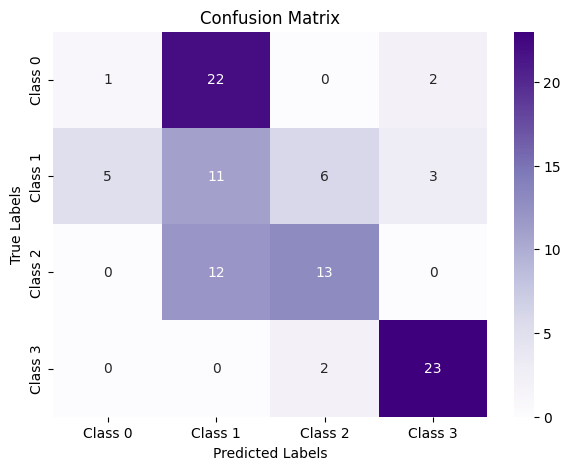

In [35]:
plt.figure(figsize=(7, 5))
sns.heatmap(cn2_conf_matrix_test, annot=True, fmt='g', cmap='Purples', xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'], yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

#### Precision, Recall, F1 Score, Accuracy

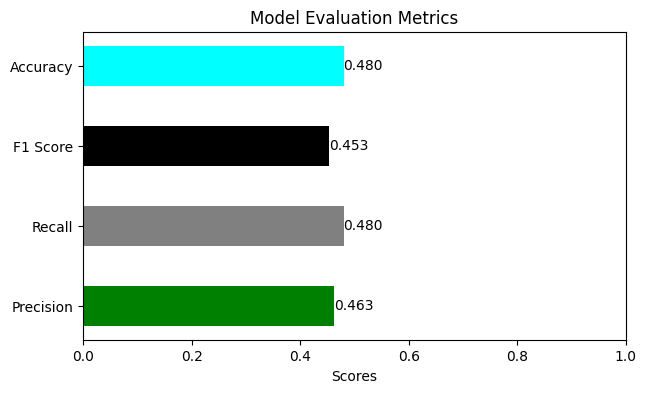

In [36]:
fig, ax = plt.subplots(figsize=(7, 4))
metrics = ['Precision', 'Recall', 'F1 Score', 'Accuracy']
scores = [cn2_precision_test, cn2_recall_test, cn2_f1_test, cn2_accuracy_test]
bar_width = 0.5

bars = ax.barh(metrics, scores, height=bar_width, color = ['green', 'grey', 'black', 'cyan'])

for bar in bars:
    plt.text(bar.get_width(), bar.get_y() + bar.get_height() / 2, f'{bar.get_width():.3f}', 
             va='center', ha='left', color='black')

ax.set_xlabel('Scores')
ax.set_title('Model Evaluation Metrics')

ax.set_xlim(0, 1)
plt.show()

#### 5fold Cross Validation

In [37]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
}

fold_metrics = []

for fold, (train_index, test_index) in enumerate(kf.split(combined_data), start=1):
    train_fold, test_fold = combined_data[train_index], combined_data[test_index]

    cn2_learner = Orange.classification.rules.CN2Learner()
    cn2_classifier = cn2_learner(train_fold)

    predicted_labels = [str(cn2_classifier(example)) for example in test_fold]
    actual_labels = [str(example.get_class()) for example in test_fold]

    fold_metrics.append({
        'accuracy': accuracy_score(actual_labels, predicted_labels),
        'precision': precision_score(actual_labels, predicted_labels, average='micro'),
        'recall': recall_score(actual_labels, predicted_labels, average='micro'),
        'f1': f1_score(actual_labels, predicted_labels, average='micro'),
    })

    print(f"Fold {fold} Metrics:")
    print(f"Accuracy: {fold_metrics[-1]['accuracy']:.4f}")
    print(f"Precision: {fold_metrics[-1]['precision']:.4f}")
    print(f"Recall: {fold_metrics[-1]['recall']:.4f}")
    print(f"F1 Score: {fold_metrics[-1]['f1']:.4f}")
    print("-" * 50)

mean_scores = {metric: np.mean([fold[metric] for fold in fold_metrics]) for metric in scoring.keys()}

print("Mean Metrics Across Folds:")
for metric, value in mean_scores.items():
    print(f"{metric}: {value:.4f}")


Fold 1 Metrics:
Accuracy: 0.9429
Precision: 0.9429
Recall: 0.9429
F1 Score: 0.9429
--------------------------------------------------
Fold 2 Metrics:
Accuracy: 0.9429
Precision: 0.9429
Recall: 0.9429
F1 Score: 0.9429
--------------------------------------------------
Fold 3 Metrics:
Accuracy: 0.9429
Precision: 0.9429
Recall: 0.9429
F1 Score: 0.9429
--------------------------------------------------
Fold 4 Metrics:
Accuracy: 0.9143
Precision: 0.9143
Recall: 0.9143
F1 Score: 0.9143
--------------------------------------------------
Fold 5 Metrics:
Accuracy: 0.9786
Precision: 0.9786
Recall: 0.9786
F1 Score: 0.9786
--------------------------------------------------
Mean Metrics Across Folds:
accuracy: 0.9443
precision: 0.9443
recall: 0.9443
f1: 0.9443


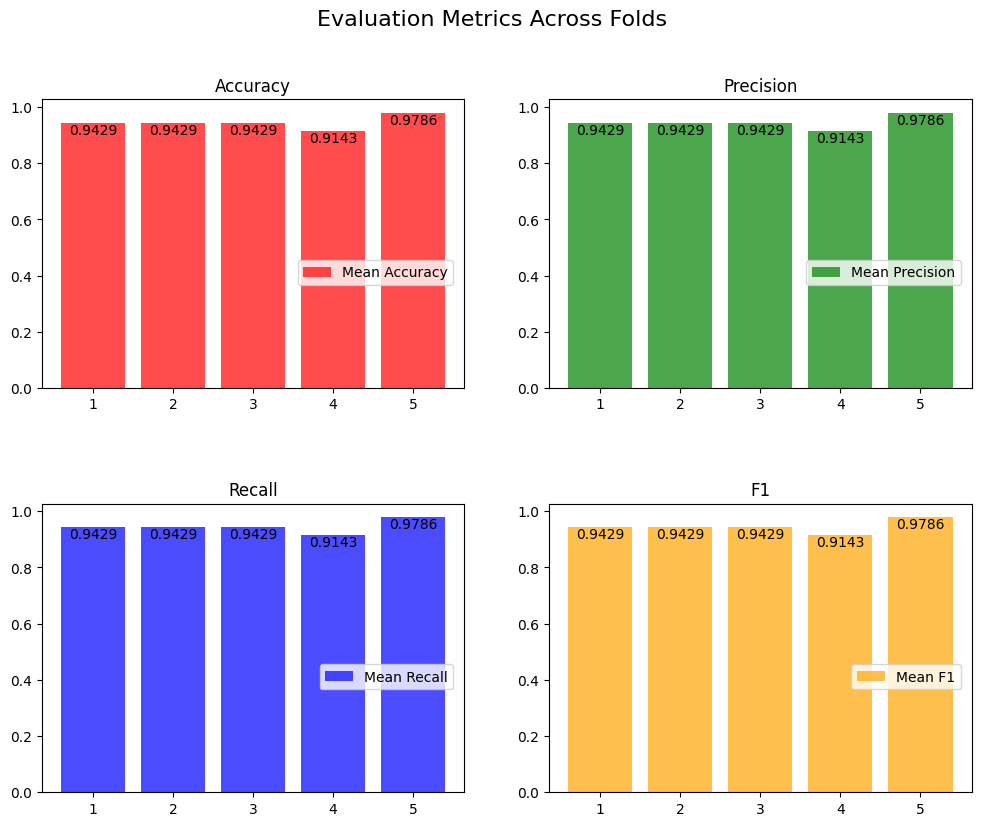

In [38]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 9))
fig.suptitle('Evaluation Metrics Across Folds', fontsize=16)

def add_values(ax, values):
    for i, value in enumerate(values):
        ax.text(i + 1, value - 0.05, f'{value:.4f}', ha='center', va='bottom', color='black')

bar_height = 0.5
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
colors = ['red', 'green', 'blue', 'orange']

for idx, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    row = idx // 2
    col = idx % 2

    metric_values = [fold[metric] for fold in fold_metrics]

    bars = axes[row, col].bar(range(1, kf.get_n_splits() + 1), metric_values, color=color, alpha=0.7)
    axes[row, col].set_title(metric.capitalize())
    add_values(axes[row, col], metric_values)

    axes[row, col].legend([f'Mean {metric.capitalize()}'], loc='center right', bbox_to_anchor=(0.99, 0.4))

plt.subplots_adjust(hspace=0.4)
plt.show()